# 03 · LiDAR 점을 RGB 이미지에 투영 (Phase 3)

**목표**: Phase 2 의 변환 체인을 실제 점군(12만 점)에 적용해 `image_02` 위에 깊이 색으로 찍고, 도로·차량 윤곽과 정렬되는지 눈으로 확인한다.

| 항목 | 내용 |
|---|---|
| 입력 | 점군 `(N, 4) float32` Velodyne · 이미지 `(375, 1242, 3) uint8 BGR` · `KittiCalibration` |
| 출력 | `uv (M, 2) float32` 픽셀 · `depth (M,) float32` m · `mask (N,) bool` (원본 점 중 살아남은 것) |
| 좌표계 | Velodyne → rect(카메라) → 픽셀. `image_shape` 인자는 **(H, W)** |
| 핵심 수식 | $[u d, v d, d]^T = P_{velo\to img}\,[x, y, z, 1]^T$ → $d>0$ 필터 → $(u, v) = (\cdot/d)$ → $0 \le u < W,\ 0 \le v < H$ |
| 실패 사례 | 카메라 뒤 점을 안 거르면 **가짜 픽셀**이 이미지 안에 찍힘 · 아주 가까운 점 · 경계 픽셀 · 센서 시차(parallax)로 인한 가장자리 배경 오염 |
| 평가 | 살아남은 점 수, uv 범위, depth > 0, 알려진 점의 위치, `tests/test_projection.py`, 오버레이 육안 확인 |

In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image, display

from perceptrack3d.config import load_config
from perceptrack3d.data.kitti_loader import KittiDataset
from perceptrack3d.geometry.calibration import KittiCalibration
from perceptrack3d.geometry.transforms import to_homogeneous
from perceptrack3d.geometry.projection import project_velo_to_image
from perceptrack3d.visualization.overlay import draw_projected_points, depth_to_color

np.set_printoptions(precision=3, suppress=True, linewidth=120)
cfg = load_config()
OUT = Path(cfg["outputs"]["dir"]) / "phase3"
OUT.mkdir(parents=True, exist_ok=True)

dataset = KittiDataset(cfg)
calib = KittiCalibration.from_dir(cfg["dataset"]["calib_dir"])
frame = dataset.load_frame(0)
image, points = frame["image"], frame["points"]
H, W = image.shape[:2]
print("image (H, W):", (H, W), "| points:", points.shape, points.dtype)
print("P_velo_to_img:\n", calib.P_velo_to_img)

image (H, W): (375, 1242) | points: (123839, 4) float32
P_velo_to_img:
 [[ 609.695 -721.422   -1.251 -123.042]
 [ 180.384    7.645 -719.651 -101.017]
 [   1.       0.       0.01    -0.269]]


## 1. 체인을 한 단계씩 — 각 단계에서 점이 몇 개 남는가

1. 동차화: `(N, 3)` → `(N, 4)`
2. 투영 행렬 곱: `(N, 4) @ (4, 3)` → `(N, 3)` = $[u d, v d, d]$
3. **카메라 앞 필터** $d > 0$ — 나누기 전에 반드시. 뒤쪽 점은 $d<0$ 이라 나누면 부호가 뒤집힌 "가짜" 픽셀이 된다.
4. 깊이로 나누어 $(u, v)$
5. 이미지 경계 필터 $0 \le u < W,\ 0 \le v < H$

In [2]:
xyz = points[:, :3]
pts_h = to_homogeneous(xyz)                                      # 1
proj = pts_h @ calib.P_velo_to_img.T                             # 2  (N, 3)
d = proj[:, 2]
print("1) homogeneous:", pts_h.shape, "| 2) proj:", proj.shape)
print(f"   depth d: min {d.min():.2f}, max {d.max():.2f} m")

in_front = d > 0                                                 # 3
u = proj[in_front, 0] / d[in_front]                              # 4
v = proj[in_front, 1] / d[in_front]
in_img = (u >= 0) & (u < W) & (v >= 0) & (v < H)                 # 5

N = len(points)
print(f"\n{'stage':34s}{'points':>9s}{'ratio':>8s}")
print(f"{'0) all LiDAR points':34s}{N:9d}{1.0:8.1%}")
print(f"{'3) in front of camera (d > 0)':34s}{in_front.sum():9d}{in_front.mean():8.1%}")
print(f"{'5) inside image bounds':34s}{in_img.sum():9d}{in_img.sum()/N:8.1%}")
print(f"\nu range [{u[in_img].min():.1f}, {u[in_img].max():.1f}] (W={W}),  v range [{v[in_img].min():.1f}, {v[in_img].max():.1f}] (H={H})")
print(f"depth of kept points: {d[in_front][in_img].min():.2f} ~ {d[in_front][in_img].max():.2f} m")

1) homogeneous: (123839, 4) | 2) proj: (123839, 3)
   depth d: min -79.23, max 77.81 m

stage                                points   ratio
0) all LiDAR points                  123839  100.0%
3) in front of camera (d > 0)         61787   49.9%
5) inside image bounds                19192   15.5%

u range [0.4, 1241.8] (W=1242),  v range [125.5, 375.0] (H=375)
depth of kept points: 4.34 ~ 77.81 m


## 2. 모듈 함수와 비교 — `project_velo_to_image`

같은 계산이 `src/perceptrack3d/geometry/projection.py` 에 있다. 반환 `mask` 는 **원본 점 인덱스**에 대한 bool 이므로
`points[mask]` 가 `uv` 와 1:1 대응한다 (Phase 5 에서 박스 안 점을 골라낼 때 이 대응이 필요하다).

In [3]:
uv, depth, mask = project_velo_to_image(points, calib, image.shape[:2])
print("uv:", uv.shape, uv.dtype, "| depth:", depth.shape, depth.dtype, "| mask:", mask.shape, mask.dtype)
print("mask.sum() == len(uv):", mask.sum() == len(uv))
manual_mask = np.zeros(N, bool); manual_mask[np.flatnonzero(in_front)[in_img]] = True
print("수동 계산과 동일? mask:", np.array_equal(mask, manual_mask),
      "| uv:", np.allclose(uv, np.stack([u[in_img], v[in_img]], 1), atol=1e-3),
      "| depth:", np.allclose(depth, d[in_front][in_img], atol=1e-3))
print("points[mask] 의 첫 3 점 (velo) →", points[mask][:3, :3], "\n→ uv:", uv[:3], " depth:", depth[:3])

uv: (19192, 2) float32 | depth: (19192,) float32 | mask: (123839,) bool
mask.sum() == len(uv): True
수동 계산과 동일? mask: True | uv: True | depth: True
points[mask] 의 첫 3 점 (velo) → [[48.373 11.554  1.891]
 [48.37  11.714  1.892]
 [68.748 25.163  2.685]] 
→ uv: [[437.056 152.781]
 [434.646 152.79 ]
 [345.018 154.149]]  depth: [48.122 48.119 68.506]


## 3. 오버레이 — 깊이를 색으로

가까운 점은 밝은 노랑, 먼 점은 어두운 보라 (`plasma` 역순, 0~70 m 고정 범위). 색 범위를 고정하면 프레임이 달라도 같은 색 = 같은 거리다.

**정렬이 맞는지 보는 법**
- 도로면: 아래쪽에서 위로 갈수록 색이 매끄럽게 멀어져야 한다(노랑 → 보라).
- 차량/사람: 물체 윤곽 안쪽의 점은 같은 색(같은 거리)이고, 윤곽 바깥 배경과 색이 확 달라야 한다.
- 점이 하늘에 찍히거나, 물체보다 좌우로 밀려 있으면 변환 순서나 (H, W) 순서가 틀린 것이다.

saved: /home/ingon/Projects/PercepTrack3D/outputs/phase3/frame0_projection_overlay.png | projected points: 19192


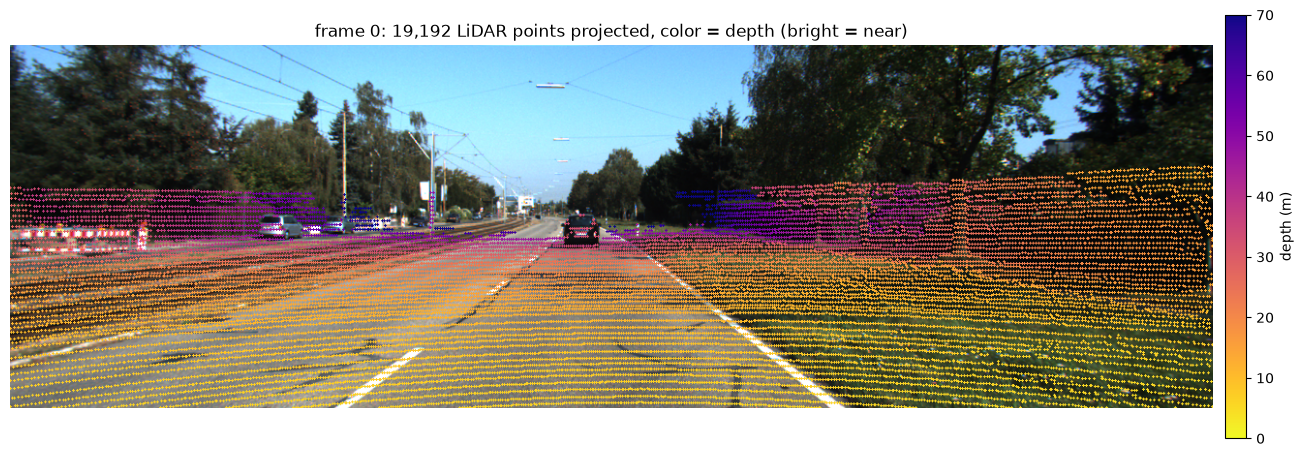

In [4]:
overlay = draw_projected_points(image, uv, depth, radius=1)
out_path = OUT / "frame0_projection_overlay.png"
cv2.imwrite(str(out_path), overlay)
print("saved:", out_path, "| projected points:", len(uv))

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); ax.axis("off")
ax.set_title(f"frame 0: {len(uv):,} LiDAR points projected, color = depth (bright = near)")
sm = plt.cm.ScalarMappable(cmap="plasma_r", norm=plt.Normalize(0, 70))
fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.01).set_label("depth (m)")
plt.show()

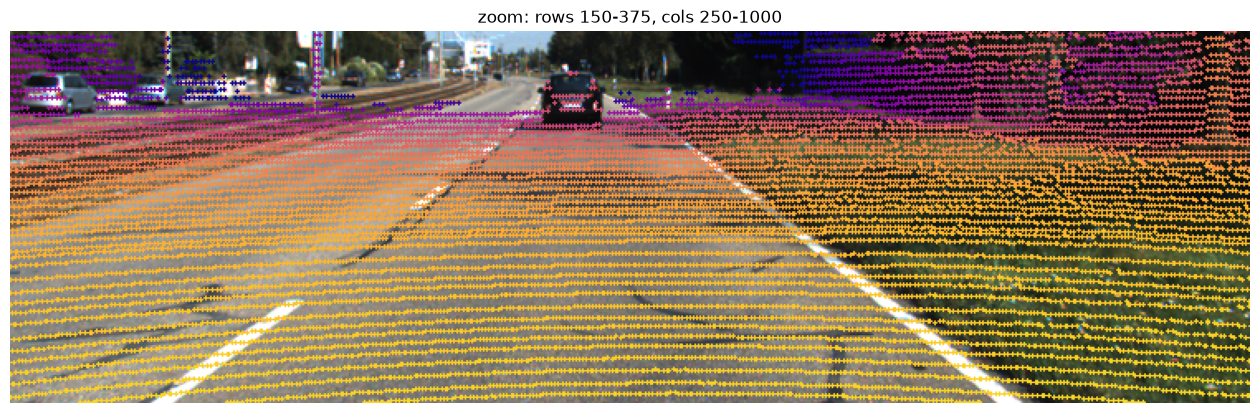

In [5]:
# 확대: 도로면과 가까운 물체 (아래쪽 절반, 가운데) — 윤곽 정렬 확인용
crop = overlay[150:375, 250:1000]
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); ax.axis("off")
ax.set_title("zoom: rows 150-375, cols 250-1000")
plt.show()

## 4. 다른 프레임 (100, 200) 도 저장

같은 캘리브레이션이 시퀀스 전체에 적용된다 (센서 고정). 프레임마다 정렬이 유지되는지 본다.

frame 100: 123,125 pts → 19,231 in image (15.6%), depth 4.2~79.1 m → frame100_projection_overlay.png


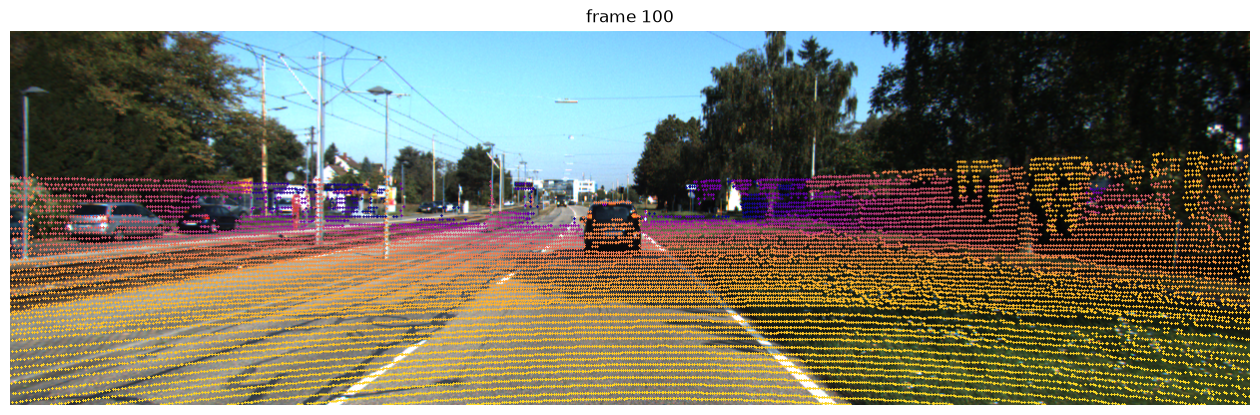

frame 200: 120,116 pts → 18,021 in image (15.0%), depth 4.9~77.8 m → frame200_projection_overlay.png


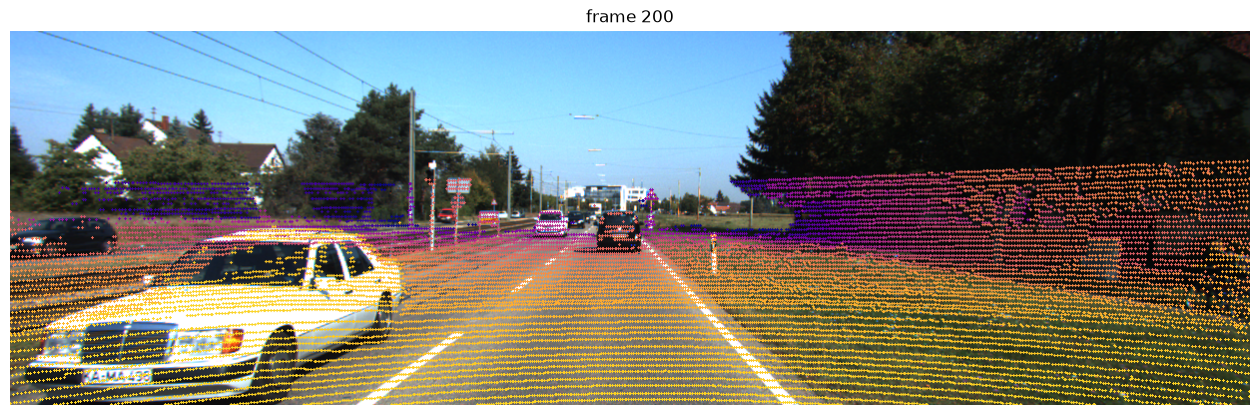

In [6]:
for fid in (100, 200):
    fr = dataset.load_frame(fid)
    uv_i, depth_i, mask_i = project_velo_to_image(fr["points"], calib, fr["image"].shape[:2])
    ov = draw_projected_points(fr["image"], uv_i, depth_i, radius=1)
    p = OUT / f"frame{fid}_projection_overlay.png"
    cv2.imwrite(str(p), ov)
    print(f"frame {fid}: {len(fr['points']):,} pts → {len(uv_i):,} in image ({mask_i.mean():.1%}), depth {depth_i.min():.1f}~{depth_i.max():.1f} m → {p.name}")
    fig, ax = plt.subplots(figsize=(16, 5.5))
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB)); ax.axis("off"); ax.set_title(f"frame {fid}")
    plt.show()

## 5. 관찰

- **도로면**: 이미지 아래에서 위로 갈수록 노랑 → 보라로 매끄럽게 멀어진다. 카메라 화각의 아래 경계(v = 374) 부근이 약 4.3 m, 지평선 근처가 70 m 이상.
- **차량**: 차체 안의 점은 한 가지 색으로 뭉쳐 있고 윤곽에서 색이 뛴다 → 변환 순서와 (H, W) 순서가 맞다는 증거.
- **하늘**: 점이 없다. 정렬이 틀리면 점 띠가 하늘로 올라간다.
- **이미지 위쪽 약 125 px 는 비어 있다**: Velodyne 의 상향 시야각(+2°)이 좁아 높은 곳은 스캔되지 않는다.
- **먼 곳**: LiDAR 64 채널의 수직 각도 간격이 커져 점 띠가 성기고, 80 m 이상은 거의 없다.

## 6. 실패 사례

1. **카메라 뒤 점을 거르지 않으면** $d<0$ 인 점이 나눗셈에서 부호가 뒤집혀 이미지 안에 "가짜 픽셀" 로 찍힌다. 아래에서 그 수를 세어 본다.
2. **아주 가까운 점** ($d$ 가 수 cm): 나누는 값이 작아 $u, v$ 가 폭주한다. 경계 필터가 걸러 주지만, 카메라 바로 앞 차체(후드) 반사점은 종종 화면 아래에 크게 찍힌다.
3. **경계 픽셀**: $u = W$ 는 이미지 밖이다 (0-based). `< W` 로 비교해야 `img[v, u]` 인덱스가 넘치지 않는다.
4. **센서 시차(parallax) → 가장자리 배경 오염**: LiDAR 는 카메라보다 0.27 m 뒤·8 cm 위에 있어 물체 가장자리에서 카메라에는 가려진 배경 점이 물체 위로 투영된다. Phase 5 의 "전경/배경 오염" 문제의 근원이다.

카메라 뒤 점: 62,052 개 중 19,054 개가 필터 없이는 이미지 안에 '가짜' 로 찍힘
depth < 5 m 인 투영점: 42 개 → v 범위 [343, 375] (이미지 아래쪽)
경계 1 px 이내 점: 68 개 (u 최대 1241.832 < 1242, v 최대 374.992 < 375)


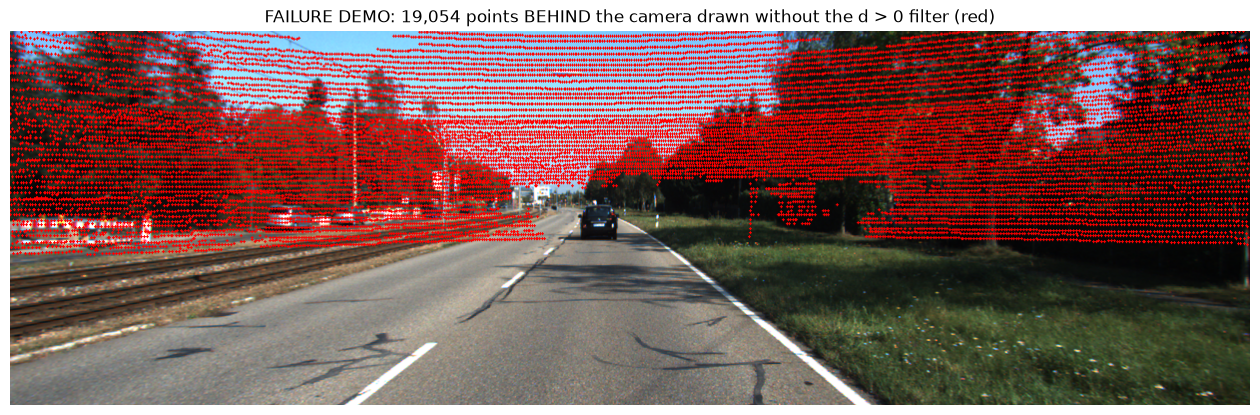

In [7]:
# (1) 카메라 뒤 점을 거르지 않았을 때 이미지 안에 떨어지는 가짜 픽셀 수
behind = ~in_front
u_all = proj[:, 0] / d
v_all = proj[:, 1] / d
fake = behind & (u_all >= 0) & (u_all < W) & (v_all >= 0) & (v_all < H)
print(f"카메라 뒤 점: {behind.sum():,} 개 중 {fake.sum():,} 개가 필터 없이는 이미지 안에 '가짜' 로 찍힘")

# (2) 아주 가까운 점: 이미지에 들어온 점 중 5 m 미만
near = depth < 5.0
print(f"depth < 5 m 인 투영점: {near.sum()} 개 → v 범위 [{uv[near, 1].min():.0f}, {uv[near, 1].max():.0f}] (이미지 아래쪽)" if near.any() else "depth < 5 m 점 없음")

# (3) 경계 1 px 안쪽에 있는 점
edge = (uv[:, 0] < 1) | (uv[:, 0] >= W - 1) | (uv[:, 1] < 1) | (uv[:, 1] >= H - 1)
print(f"경계 1 px 이내 점: {edge.sum()} 개 (u 최대 {uv[:, 0].max():.3f} < {W}, v 최대 {uv[:, 1].max():.3f} < {H})")

# 가짜 픽셀을 실제로 그려 보면 어디에 찍히는지: 필터 없는 오버레이 (빨간 점)
wrong = image.copy()
for uu, vv in zip(u_all[fake].astype(int), v_all[fake].astype(int)):
    cv2.circle(wrong, (int(uu), int(vv)), 1, (0, 0, 255), -1)
fig, ax = plt.subplots(figsize=(16, 5.5))
ax.imshow(cv2.cvtColor(wrong, cv2.COLOR_BGR2RGB)); ax.axis("off")
ax.set_title(f"FAILURE DEMO: {fake.sum():,} points BEHIND the camera drawn without the d > 0 filter (red)")
plt.show()

## 7. 정리

- **입력/출력**: `(N, 4)` 점군 + 캘리브레이션 + `(H, W)` → `uv (M, 2)`, `depth (M,)`, `mask (N,)`.
- **좌표계**: Velodyne → rect → 픽셀. `image_shape` 는 `image.shape[:2]` 그대로 = **(H, W)**.
- **핵심 수식**: $[ud, vd, d] = P_{velo\to img}[x, y, z, 1]$; $d>0$ 먼저, 나누기, 경계.
- **실패 사례**: 뒤쪽 점 미필터(가짜 픽셀), 초근접점, 경계 `<` vs `<=`, 센서 시차로 인한 가장자리 배경 점.
- **평가**: `tests/test_projection.py` (뒤쪽 점 제외, 경계, depth>0, 알려진 점, `mask.sum()==len(uv)`) + 오버레이 육안 확인.

### 자가 점검 질문
1. 왜 $d>0$ 필터를 **나누기 전에** 해야 하는가? 나눈 뒤에 걸러도 결과가 같은가?
2. `project_velo_to_image` 의 `mask` 로 `points[mask]` 를 하면 `uv` 와 어떤 대응 관계가 생기며, Phase 5 에서 이것이 왜 필요한가?
3. 이미지 안에 들어온 점이 전체의 약 15 % 뿐인 이유 두 가지는 무엇인가? (힌트: 시야각, 뒤쪽)